# Ch 16 — MNIST 손글씨 분류 (CNN)

원본: `deep_code/14_MNIST_CNN.py`

다루는 내용:
1. MNIST 데이터 로드 (`keras.datasets`)
2. 이미지 시각화 + 데이터 분포 확인
3. 채널 차원 추가 + 정규화 (`/255.0`)
4. Conv2D → MaxPool → Flatten → Dense 모델
5. 학습 곡선과 test accuracy
6. 틀린 샘플 시각화

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

2026-05-14 12:55:15.344245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778730915.369565 2254225 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778730915.377372 2254225 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터 로드

첫 실행 시 `~/.keras/datasets/mnist.npz` 로 자동 다운로드 (~11MB).

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, "고유 라벨:", np.unique(y_train))
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("학습 데이터 클래스 분포:", np.bincount(y_train))

X_train: (60000, 28, 28) uint8
y_train: (60000,) 고유 라벨: [0 1 2 3 4 5 6 7 8 9]
X_test : (10000, 28, 28)
y_test : (10000,)
학습 데이터 클래스 분포: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


## 2. 샘플 시각화

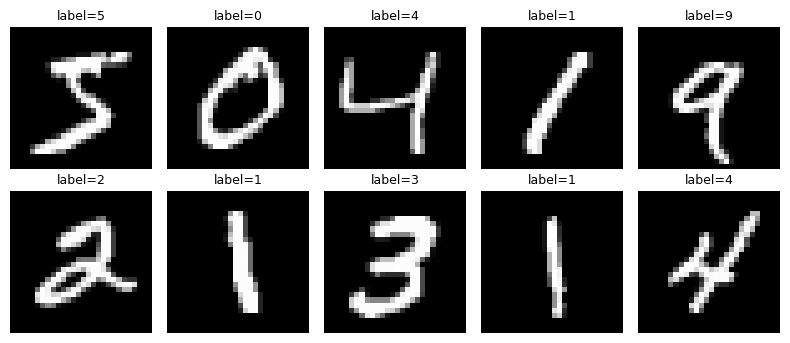

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"label={y_train[i]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. 전처리

- 채널 차원 추가: `(N, 28, 28)` → `(N, 28, 28, 1)`. Conv2D 는 4D 텐서를 받음.
- 정규화: 0–255 정수 → 0–1 float. 학습 안정성 ↑.

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print("X_train:", X_train.shape, "min:", X_train.min(), "max:", X_train.max())
print("X_test :", X_test.shape)

X_train: (60000, 28, 28, 1) min: 0.0 max: 1.0
X_test : (10000, 28, 28, 1)


## 4. 모델 — CNN

```
Input(28,28,1)
 → Conv2D(32, 3x3, relu)   # (26,26,32)
 → Conv2D(64, 3x3, relu)   # (24,24,64)
 → MaxPool(2,2)            # (12,12,64)
 → Dropout(0.25)
 → Flatten                 # 9216
 → Dense(128, relu)
 → Dropout(0.5)
 → Dense(10, softmax)
```

In [5]:
keras.utils.set_random_seed(0)
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu"),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax"),
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)
model.summary()

2026-05-14 12:55:18.868436: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

**왜 `sparse_categorical_crossentropy`?** 라벨이 정수 (0–9) 그대로라서 `to_categorical` 로 one-hot 만들지 않아도 됨. 메모리 절약 + 코드 한 줄 줄어듦. (ch12 iris 의 마무리 체크리스트와 같은 패턴.)

## 5. 학습

CPU 기준 5 epoch ~5–8분. validation_split 으로 진짜 일반화 성능 측정.

In [6]:
hist = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1,
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9234 - loss: 0.2478 - val_accuracy: 0.9828 - val_loss: 0.0577
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9735 - loss: 0.0879 - val_accuracy: 0.9880 - val_loss: 0.0409
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9799 - loss: 0.0662 - val_accuracy: 0.9890 - val_loss: 0.0391
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9829 - loss: 0.0536 - val_accuracy: 0.9895 - val_loss: 0.0364
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9859 - loss: 0.0435 - val_accuracy: 0.9898 - val_loss: 0.0378


## 6. 학습 곡선

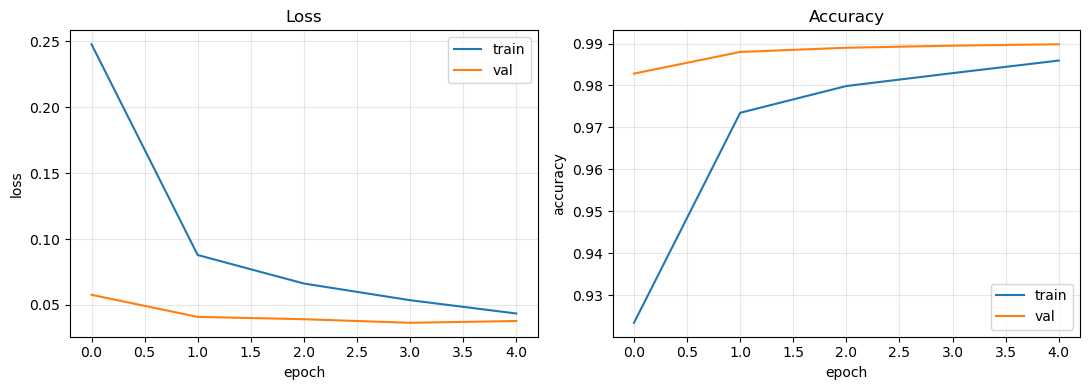

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist.history["loss"], label="train")
ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Loss")

ax[1].plot(hist.history["accuracy"], label="train")
ax[1].plot(hist.history["val_accuracy"], label="val")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[1].set_title("Accuracy")
plt.tight_layout(); plt.show()

## 7. 테스트셋 평가

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"test loss     : {test_loss:.4f}")
print(f"test accuracy : {test_acc:.4f}")

test loss     : 0.0286
test accuracy : 0.9907


## 8. 틀린 샘플 시각화

CNN 이 어떤 숫자를 헷갈리는지 직접 보기.

틀린 개수: 93 / 10000  (0.93%)


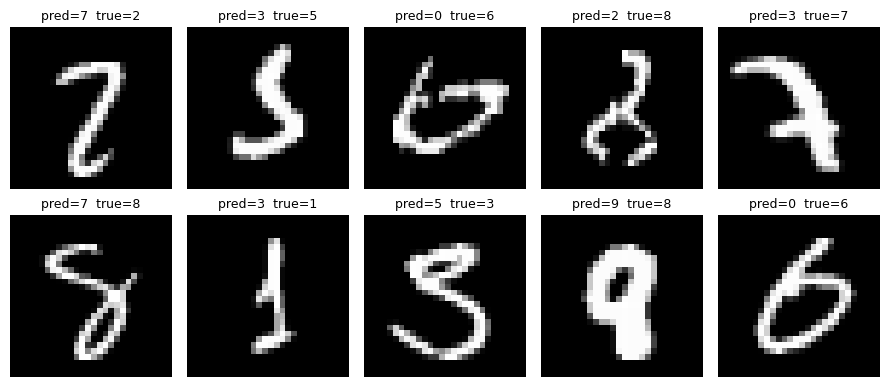

In [9]:
probs = model.predict(X_test, verbose=0)
preds = np.argmax(probs, axis=1)
wrong = np.where(preds != y_test)[0]
print(f"틀린 개수: {len(wrong)} / {len(y_test)}  ({len(wrong)/len(y_test)*100:.2f}%)")

show = wrong[:10]
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, idx in zip(axes.flat, show):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"pred={preds[idx]}  true={y_test[idx]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 마무리 체크리스트
- [ ] `model.summary()` 에서 첫 Conv2D 출력이 `(26, 26, 32)` 인지 확인 — 3×3 필터는 양쪽 1픽셀씩 잘림
- [ ] MaxPool 후 shape 가 `(12, 12, 64)` 로 절반이 되는지
- [ ] 5 epoch 만에 test accuracy 0.99 근처까지 가는지
- [ ] 틀린 샘플들 — 4↔9, 3↔5, 7↔1 처럼 사람도 헷갈릴 만한 형태인지
- [ ] Dense 만 썼던 ch10–15 와 비교: 위치 정보를 보존한다는 게 어떤 차이를 만드는지